# E5c - Anchor mask control (reproducer)

Top-to-bottom reproducer for `docs/experiments/E5c-anchor-mask-control.md`.

## Design

Four conditions per question:
1. `target_only` (base image)
2. `target_plus_irrelevant_number_S{1..5}` (base + anchor image, digit visible)
3. `target_plus_irrelevant_number_masked_S{1..5}` (base + same anchor scene with the digit pixel region inpainted out)
4. `target_plus_irrelevant_neutral` (base + a generic neutral image; no digit, unrelated content)

## Comparisons of interest

- `(1, 2, 3)` - digit pixel causality. (1->2) total anchor effect; (1->3) effect with digit removed; (2 - 3) = pure digit-pixel contribution.
- `(1, 3, 4)` - anchor-image-background contribution beyond generic 2-image distraction. (1->3) and (1->4) should match if the anchor scene's background offers no extra info.

## Headline metric

`adopt_cond` (paired conditional anchor adoption, M1; denominator = case 1 + 2 + 3 = excludes case 4 `base==a==pred`). Undefined for neutral (no anchor value).

Direction-follow (`df_uncond`, `df_cond`) and accuracy drop (`acc_drop`) are also reported so the user can see the (1,3,4) `acc_drop` comparison and the `df` quirk that both anchor and masked produce nearly the same `df_cond` on wrong-base records (model uncertainty, not digit-specific signal).


In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'scripts'))
from analyze_e5c_distance import run
out = run()
summary = out['summary']
print(f"loaded {out['n_records']} records, wrote {out['out_csv']}")
import pandas as pd
pd.set_option('display.float_format', '{:0.4f}'.format)

/mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/scripts/analyze_e5c_distance.py:280: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xs, rotation=60, fontsize=8)
/mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/scripts/analyze_e5c_distance.py:280: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xs, rotation=60, fontsize=8)
/mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/scripts/analyze_e5c_distance.py:280: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xs, rotation=60, fontsize=8)
/mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/scripts/analyze_e5c_distance.py:280: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator

loaded 24000 records, wrote docs/insights/_data/E5c_per_cell.csv


## base = all

In [2]:
summary[summary['base']=='all'][['dataset','condition_type','stratum','n','adopt_cond','df_uncond','df_cond','acc_drop']]

,dataset,condition_type,stratum,n,adopt_cond,df_uncond,df_cond,acc_drop
0,VQAv2,anchor,S1,1000,0.1074,0.1870,0.1952,0.0140
1,VQAv2,anchor,S2,1000,0.0306,0.2780,0.2633,0.0303
2,VQAv2,anchor,S3,1000,0.0200,0.2050,0.2042,0.0370
3,VQAv2,anchor,S4,1000,0.0160,0.1900,0.1900,0.0343
4,VQAv2,anchor,S5,1000,0.0130,0.1840,0.1840,0.0313
5,VQAv2,masked,S1,1000,0.0581,0.1680,0.1594,0.0113
6,VQAv2,masked,S2,1000,0.0071,0.2590,0.2454,0.0087
7,VQAv2,masked,S3,1000,0.0020,0.1880,0.1872,0.0087
8,VQAv2,masked,S4,1000,0.0000,0.1820,0.1820,0.0230
9,VQAv2,masked,S5,1000,0.0000,0.1690,0.1690,0.0073


## base = correct

In [3]:
summary[summary['base']=='correct'][['dataset','condition_type','stratum','n','adopt_cond','df_uncond','df_cond','acc_drop']]

,dataset,condition_type,stratum,n,adopt_cond,df_uncond,df_cond,acc_drop
12,VQAv2,anchor,S1,601,0.0898,0.0682,0.1088,0.0932
13,VQAv2,anchor,S2,601,0.0349,0.1015,0.1015,0.1048
14,VQAv2,anchor,S3,601,0.0216,0.0715,0.0715,0.1093
15,VQAv2,anchor,S4,601,0.0183,0.0632,0.0632,0.0993
16,VQAv2,anchor,S5,601,0.0166,0.0599,0.0599,0.0987
17,VQAv2,masked,S1,601,0.0500,0.0416,0.0663,0.0754
18,VQAv2,masked,S2,601,0.0067,0.0699,0.0699,0.0715
19,VQAv2,masked,S3,601,0.0000,0.0466,0.0466,0.0754
20,VQAv2,masked,S4,601,0.0000,0.0433,0.0433,0.0782
21,VQAv2,masked,S5,601,0.0000,0.0316,0.0316,0.0621


## base = wrong

In [4]:
summary[summary['base']=='wrong'][['dataset','condition_type','stratum','n','adopt_cond','df_uncond','df_cond','acc_drop']]

,dataset,condition_type,stratum,n,adopt_cond,df_uncond,df_cond,acc_drop
24,VQAv2,anchor,S1,399,0.1292,0.3659,0.3564,-0.1053
25,VQAv2,anchor,S2,399,0.0237,0.5439,0.5198,-0.0819
26,VQAv2,anchor,S3,399,0.0176,0.4060,0.4045,-0.0718
27,VQAv2,anchor,S4,399,0.0125,0.3810,0.3810,-0.0635
28,VQAv2,anchor,S5,399,0.0075,0.3709,0.3709,-0.0702
29,VQAv2,masked,S1,399,0.0681,0.3584,0.3350,-0.0852
30,VQAv2,masked,S2,399,0.0079,0.5439,0.5223,-0.0860
31,VQAv2,masked,S3,399,0.0050,0.4010,0.3995,-0.0919
32,VQAv2,masked,S4,399,0.0000,0.3910,0.3910,-0.0602
33,VQAv2,masked,S5,399,0.0000,0.3759,0.3759,-0.0752


## Figure 1 - anchor vs masked x base correctness, adopt_cond

Anchor > masked at S1 on both datasets and both base subsets. The gap (anchor - masked) is the pure digit-pixel contribution to paired adoption.

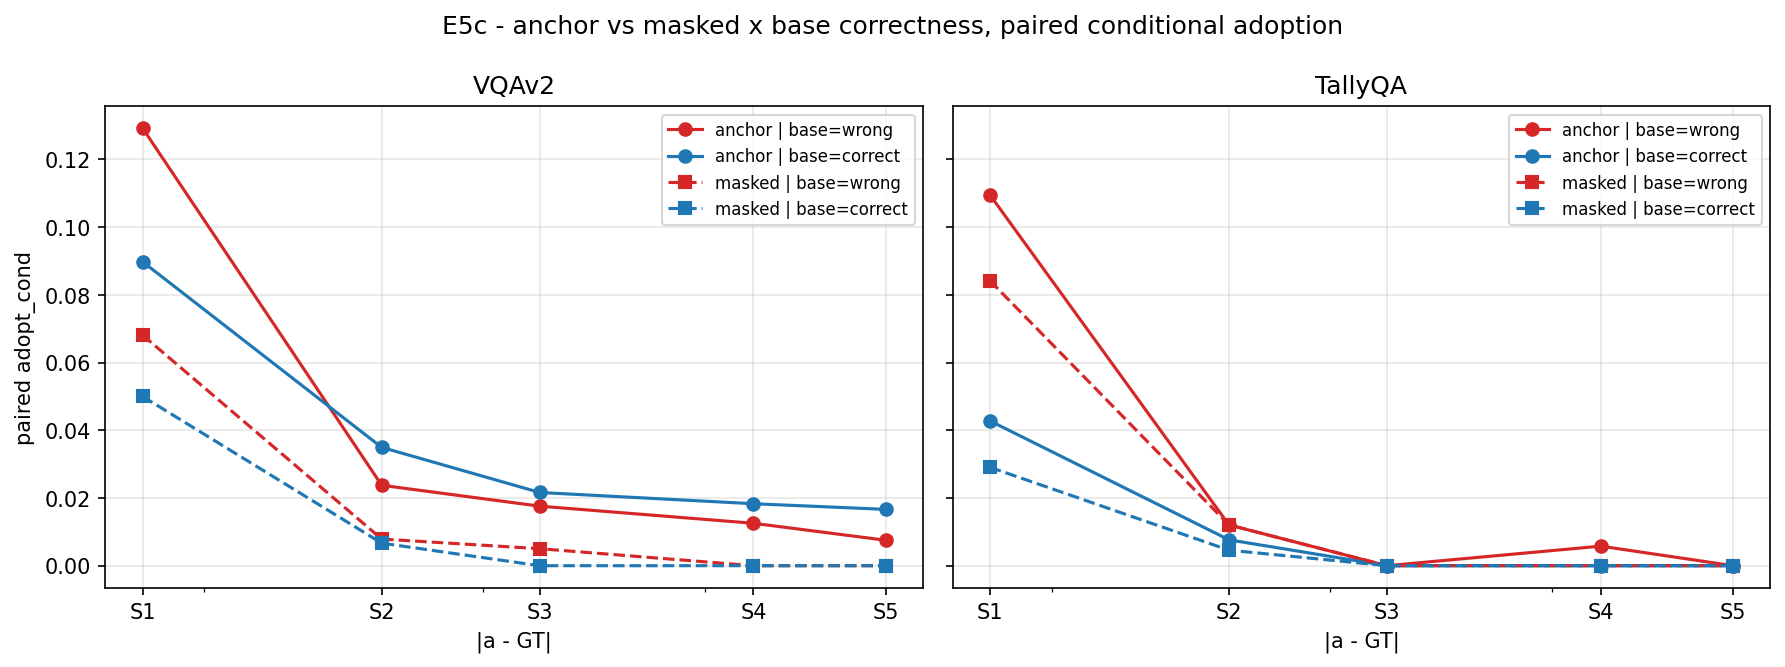

In [5]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / 'docs' / 'figures' / 'E5c_anchor_vs_masked_adopt.png')))

## Figure 2 - direction-follow does NOT isolate the digit

On wrong-base records, `df_cond` is essentially identical for anchor and masked at S2 (~0.52 VQAv2, ~0.46 TallyQA) and within a few pp at S1. The model's prediction shifts toward the anchor side regardless of whether the digit is visible - the second image's *presence* is enough to perturb predictions for uncertain models. Use `adopt_cond` (where pred lands exactly on anchor) to get the digit-specific signal.

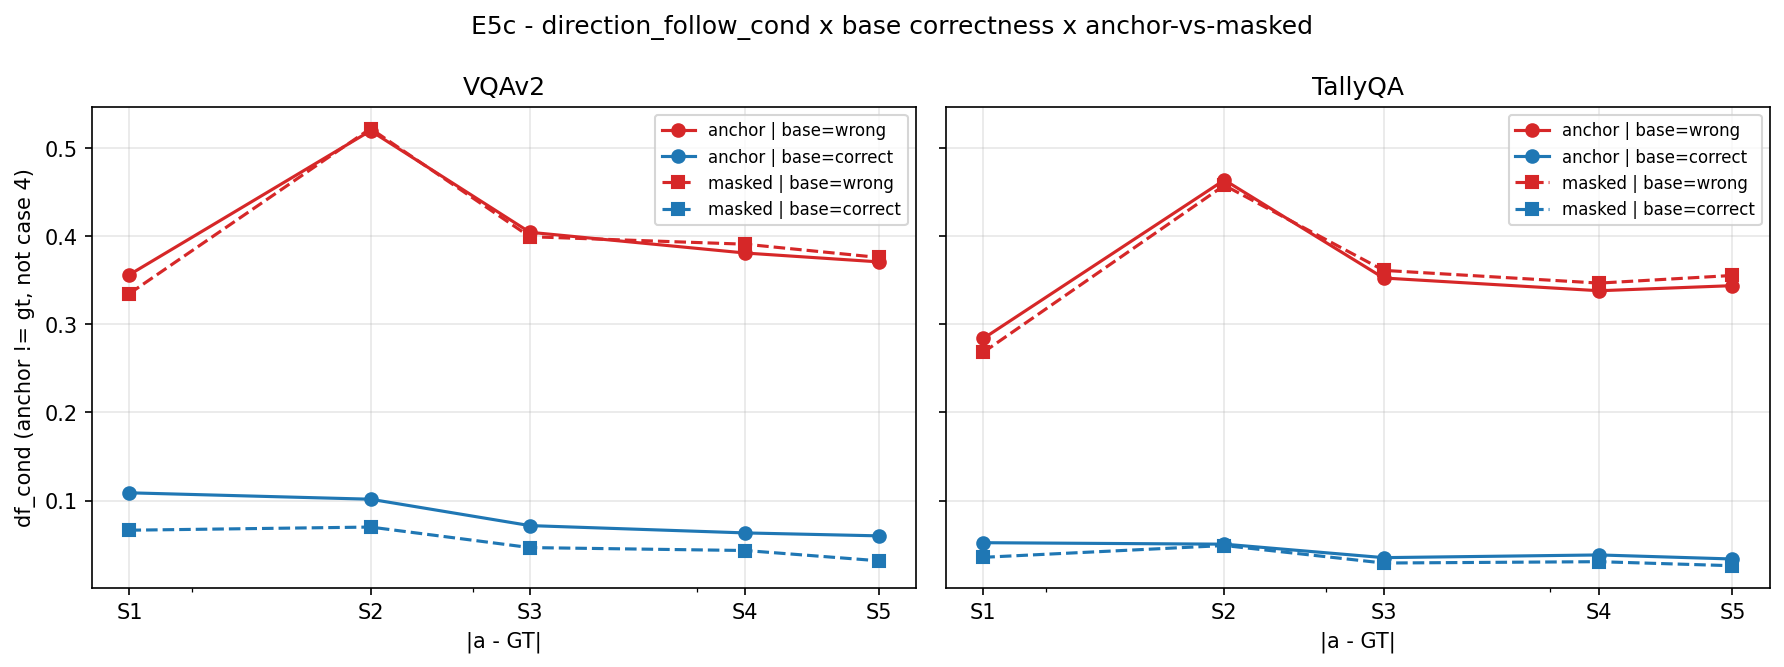

In [6]:
display(Image(filename=str(ROOT / 'docs' / 'figures' / 'E5c_anchor_vs_masked_df.png')))

## Figure 3 - `acc_drop`: masked ~ neutral << anchor (on the meaningful base subsets)

Comparing target_only's accuracy to each treatment's accuracy on the SAME base subset:
- `correct-base` (model knows the answer baseline-side): all three distractors hurt accuracy, but masked and neutral hurt about the same (~7-9 pp on VQAv2, ~2-5 pp on TallyQA). Anchor hurts measurably more.
- `wrong-base`: `acc_drop` is negative (regression-to-mean: distraction nudges some wrong predictions back to correct). Not informative.
- The masked image acts like a generic neutral distractor on accuracy. The anchor image's *background* offers no extra information beyond generic 2-image distraction.

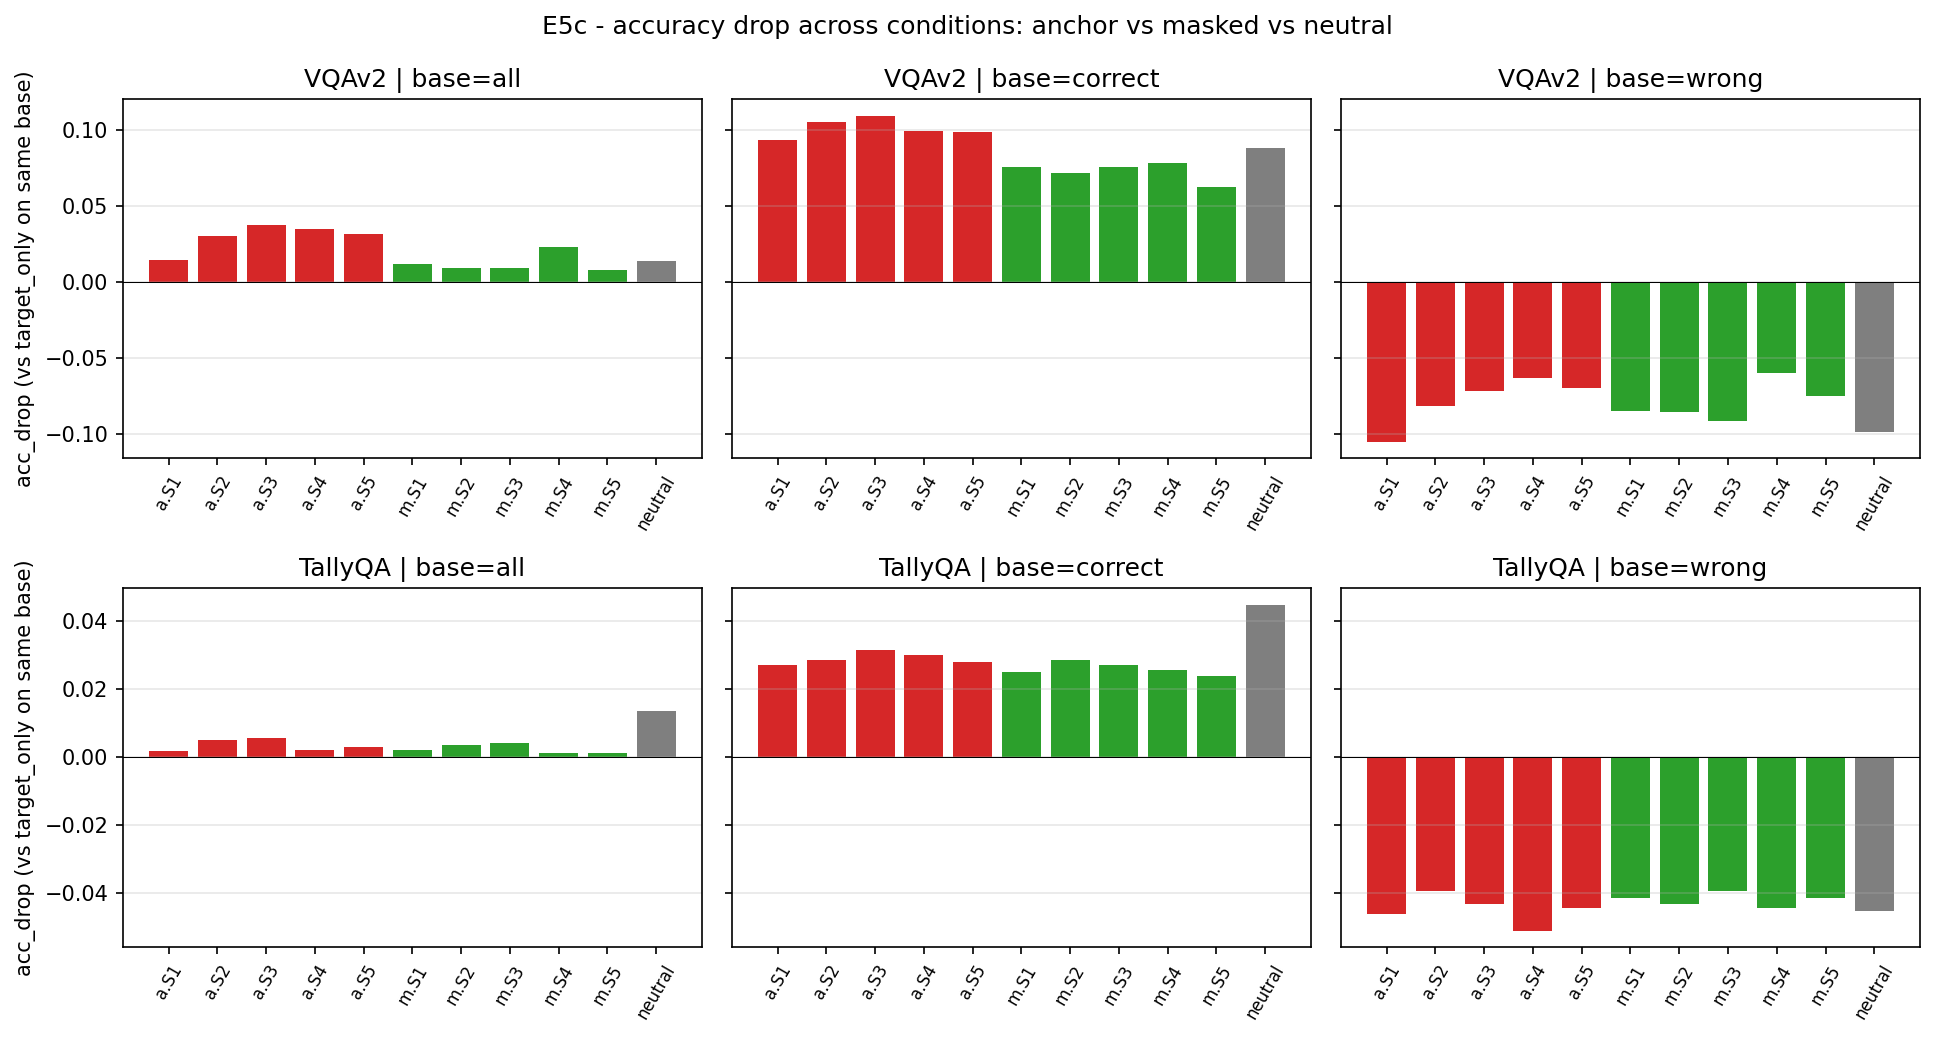

In [7]:
display(Image(filename=str(ROOT / 'docs' / 'figures' / 'E5c_acc_drop_3way.png')))

## Figure 4 - sanity check vs E5b: uncertainty gate still holds

Reproducing the E5b finding on the E5c run: anchor adopt_cond decays with distance, with wrong-base higher than correct-base.

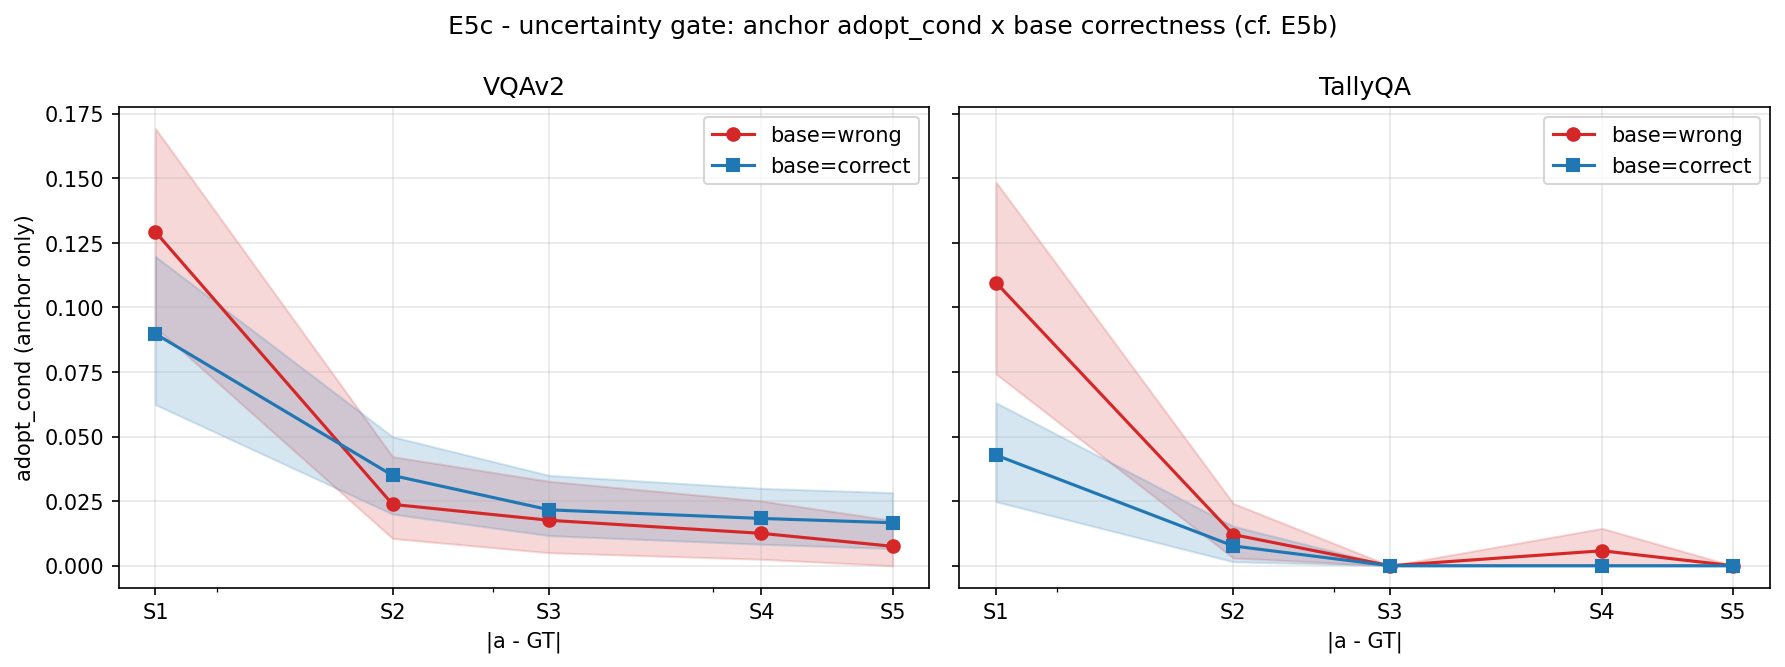

In [8]:
display(Image(filename=str(ROOT / 'docs' / 'figures' / 'E5c_correct_vs_wrong_adopt.png')))

## Distilled digit-pixel gap

Anchor - masked on wrong-base, paired conditional adoption.

In [9]:
for ds in ['VQAv2', 'TallyQA']:
    rows = summary[(summary['dataset']==ds) & (summary['base']=='wrong')]
    anchor = rows[rows['condition_type']=='anchor'].set_index('stratum')['adopt_cond']
    masked = rows[rows['condition_type']=='masked'].set_index('stratum')['adopt_cond']
    print(f'\n{ds}  wrong-base anchor - masked:')
    for s in ['S1','S2','S3','S4','S5']:
        print(f'  {s}: anchor={anchor.get(s, float("nan")):.4f}  masked={masked.get(s, float("nan")):.4f}  gap={anchor.get(s,0) - masked.get(s,0):+.4f}')


VQAv2  wrong-base anchor - masked:
  S1: anchor=0.1292  masked=0.0681  gap=+0.0611
  S2: anchor=0.0237  masked=0.0079  gap=+0.0159
  S3: anchor=0.0176  masked=0.0050  gap=+0.0126
  S4: anchor=0.0125  masked=0.0000  gap=+0.0125
  S5: anchor=0.0075  masked=0.0000  gap=+0.0075

TallyQA  wrong-base anchor - masked:
  S1: anchor=0.1095  masked=0.0842  gap=+0.0253
  S2: anchor=0.0120  masked=0.0120  gap=+0.0000
  S3: anchor=0.0000  masked=0.0000  gap=+0.0000
  S4: anchor=0.0058  masked=0.0000  gap=+0.0058
  S5: anchor=0.0000  masked=0.0000  gap=+0.0000
